# Question1

In [151]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

In [152]:
n=3 
N=8
solution = '101'

In [153]:
#define oracle function for '101'
def grover_oracle():
    solution = 101
    qc = QuantumCircuit(3)
    #apply x gate on second qubit
    qc.x(1)
    # creating controlled Z from controlled X using Hadamard as HXH=Z
    qc.h(2)
    qc.mcx(list(range(2)),2)
    qc.h(2)
    #again applying x gate because our target is '101' and CZ works on '111'
    qc.x(1)
    oracle_gate = qc.to_gate()
    oracle_gate.name = "Oracle"
    return oracle_gate


In [154]:
#defining the diffuser for 3 qubit system
def grover_diffuser():
    qc = QuantumCircuit(3)
    #first applying hadamard gate
    qc.h(range(3))
    #The below lines are used to change |0n> basis state to -|0n> basis state
    qc.x(range(3))
    qc.h(2)
    qc.mcx(list(range(2)),2)
    qc.h(2)
    qc.x(range(2))
    #final hadamard
    qc.h(range(3))
    diffuser_gate = qc.to_gate() # converts the circuit to gate
    diffuser_gate.name = "Diffuser"
    return diffuser_gate 

In [155]:
iterations = 2 #for 3 qubits

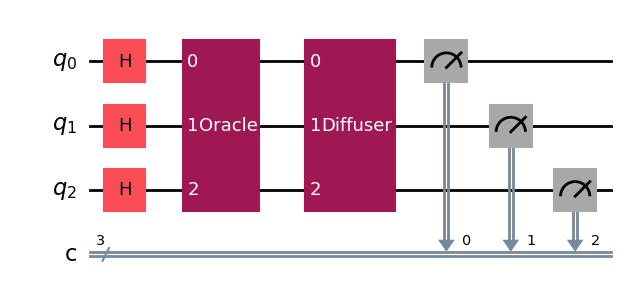

In [156]:
qc = QuantumCircuit(3,3) #Quantum circuit of 3 qubits and 3 classical bits

qc.h(range(3))
oracle = grover_oracle()
diffuser = grover_diffuser()
#add these respective components in front of the quantum circuit
qc.append(oracle, range(3))
qc.append(diffuser, range(3))
# qc.append(oracle, range(3))
# qc.append(diffuser, range(3))

qc.measure( range(3), range(3))
qc.draw('mpl')

In [157]:
# The above diagram is by applying the oracle and diffuser once.
# Let's also find the probability with which we will get target state now.

{'101': 1592, '010': 72, '111': 66, '000': 68, '011': 68, '100': 59, '001': 55, '110': 68}


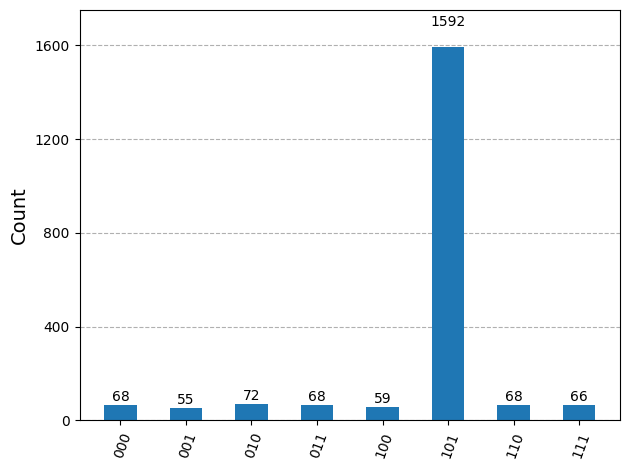

In [158]:
from qiskit import transpile

backend = AerSimulator()
shots = 2048

transpiled_qc = transpile(qc, backend)

result = backend.run(transpiled_qc, shots = shots).result()
counts = result.get_counts(transpiled_qc)
print(counts)
plot_histogram(counts)
# the below error because I commented the measure line.

In [159]:
#The first probability is 0.795

In [160]:
# #let's find the result of second measurement
# qc.append(oracle, range(3))
# qc.append(diffuser, range(3))
# qc.measure( range(3), range(3))

# from qiskit import transpile
# backend = AerSimulator()
# shots = 2048

# # Transpile the circuit to the backend's basis gates
# transpiled_qc = transpile(qc, backend)

# result = backend.run(transpiled_qc, shots=shots).result()
# counts = result.get_counts(transpiled_qc)
# print(counts)
# plot_histogram(counts)

In [161]:
# The probability is 0.36 
# My second probability result is not coming correct.

# Bonus

 For generalizing for any target state we just need to change the Oracle code.

In [162]:
def grover_oracle(n=3, solution):
    qc = QuantumCircuit(n)
    for qubit, bit in enumerate(reversed(solution)):
        if bit == '0':
            qc.x(qubit)
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)  # Multi-controlled X (Toffoli)
    qc.h(n - 1)
    for qubit, bit in enumerate(reversed(solution)):
        if bit == '0':
            qc.x(qubit)
    oracle_gate = qc.to_gate()
    oracle_gate.name = "Oracle"
    return oracle_gate

SyntaxError: parameter without a default follows parameter with a default (697980753.py, line 1)

For 4 Qubit general state

In [ ]:
n=4
N=16
solution='1111'

In [ ]:
def grover_oracle2(n, solution):
    qc = QuantumCircuit(n)
    for qubit, bit in enumerate(reversed(solution)):
        if bit == '0':
            qc.x(qubit)
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1) 
    qc.h(n - 1)
    for qubit, bit in enumerate(reversed(solution)):
        if bit == '0':
            qc.x(qubit)
    oracle_gate = qc.to_gate()
    oracle_gate.name = "Oracle"
    return oracle_gate

In [ ]:
def grover_diffuser2(n):
    qc = QuantumCircuit(n)
    qc.h(range(n))
    qc.x(range(n))
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1) 
    qc.h(n - 1)
    qc.x(range(n))
    qc.h(range(n))
    diffuser_gate = qc.to_gate()
    diffuser_gate.name = "Diffuser"
    return diffuser_gate

In [ ]:
#using formula
iterations=3

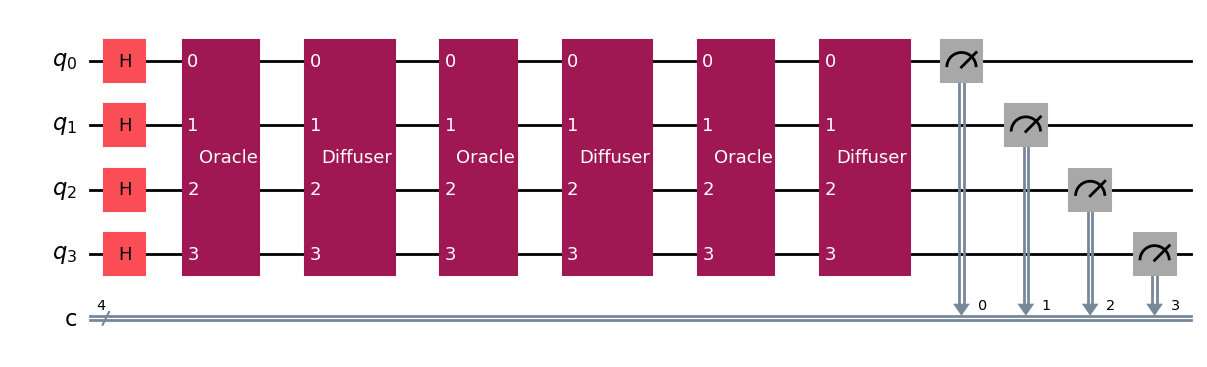

In [ ]:
qc=QuantumCircuit(n,n)

qc.h(range(n))

oracle = grover_oracle2(n, solution)
diffuser = grover_diffuser2(n)

for _ in range(iterations):
    qc.append(oracle, range(n))
    qc.append(diffuser, range(n))

qc.measure(range(n), range(n))

qc.draw('mpl')

{'0110': 5, '1111': 986, '0011': 4, '1100': 4, '1110': 2, '1000': 4, '1101': 1, '1010': 3, '1001': 2, '0001': 2, '0000': 4, '1011': 3, '0010': 2, '0111': 2}


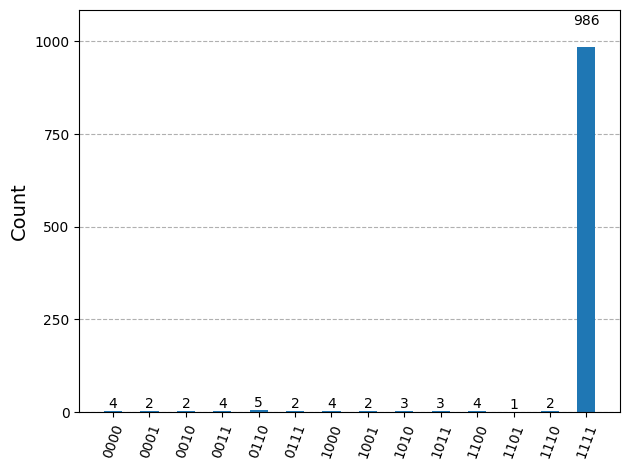

In [ ]:
from qiskit import transpile

backend = AerSimulator()
shots = 1024

transpiled_qc = transpile(qc, backend)

result = backend.run(transpiled_qc, shots=shots).result()
counts = result.get_counts(transpiled_qc)
print(counts)
plot_histogram(counts)

probability is 0.96

# Question2

In [ ]:
from qiskit.circuit.library import PhaseOracle
import numpy as np

In [203]:
n=3
N=2 ** n
M=1
iteration=int(np.floor(((np.pi) / 4) * (np.sqrt(N)/np.sqrt(M))))
print(iteration)

2


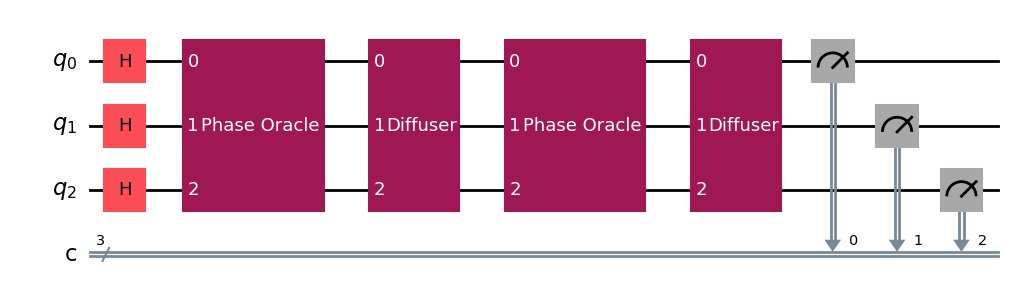

In [204]:
qc=QuantumCircuit(3,3)
DIMACS_CNF = "(x1 | ~x2 | x3) & (~x1 | x2 | x3)"
qc.h(range(n)) 
diffuser=grover_diffuser()
oracle=PhaseOracle(DIMACS_CNF)
for i in range(iteration):
    qc.append(oracle, range(n))
    qc.append(diffuser, range(n))

qc.measure(range(n),range(n))
qc.draw('mpl')

{'101': 138, '000': 147, '011': 124, '111': 126, '100': 133, '010': 126, '001': 111, '110': 119}


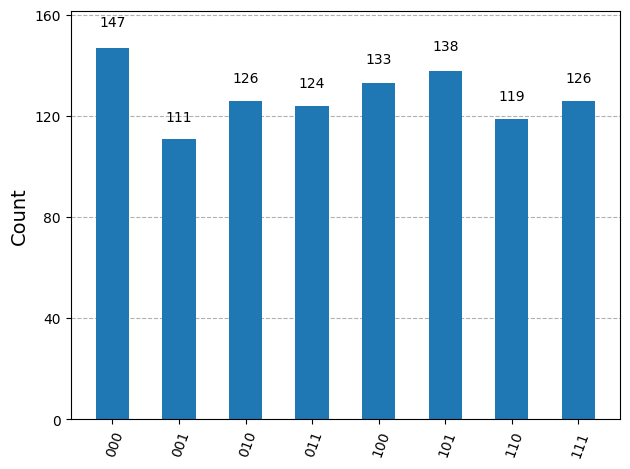

In [205]:
from qiskit import transpile

backend = AerSimulator()
shots = 1024

transpiled_qc = transpile(qc, backend)

result = backend.run(transpiled_qc, shots=shots).result()
counts = result.get_counts(transpiled_qc)
print(counts)
plot_histogram(counts)